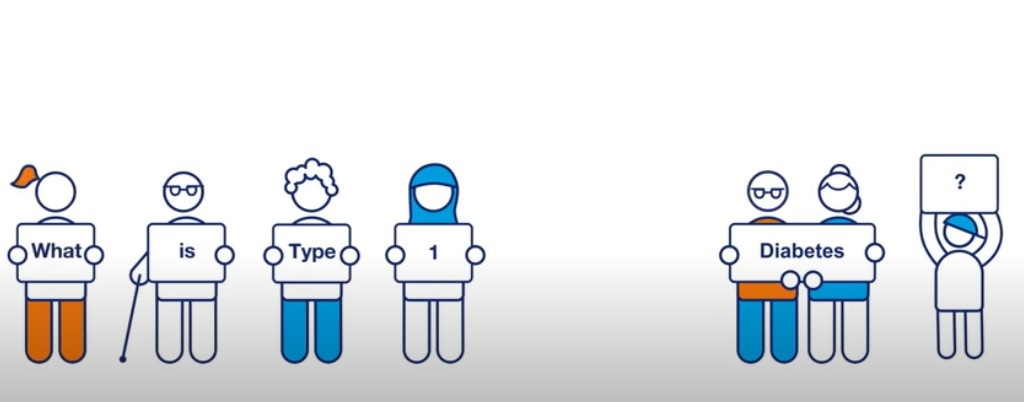

### 📌**Business Problem :**

* It is desired to develop a machine learning model that can predict whether people have diabetes when their characteristics are specified. You are expected to perform the necessary data analysis and feature engineering steps before developing the model.

### 📌**Dataset Story :**

*  The dataset is part of the large dataset held at the National Institutes of Diabetes-Digestive-Kidney Diseases in the USA. are data. The target variable is specified as "Outcome"; 1 indicates positive diabetes test result, 0 indicates negative.

### 📌**Variables :**
* Pregnancies    : Number of pregnancies
* Glucose        : 2-hour plasma glucose concentration in the oral glucose tolerance test
* Blood Pressure : Blood Pressure (Smallness) (mm Hg)
* SkinThickness  : Skin Thickness
* Insulin        : 2-hour serum insulin (mu U/ml)
* Diabetes Pedigree Function : Function (2 hour plasma glucose concentration in oral glucose tolerance test)
* BMI            : Body mass index
* Age            : Age (years)
* Outcome        : Have the disease(1) or not (0)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


### ⏬ 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
# !pip install missingno
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

In [3]:
# some adjustments 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

### 🔎 Reading the Dataset

In [4]:
df_ = pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')
df = df_.copy()

In [5]:
# auxiliary functions
def check_df(dataframe):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(3))
    print("##################### Tail #####################")
    print(dataframe.tail(3))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)


def grab_col_names(dataframe, cat_th=10, car_th=20):
    """

    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.
    Not: Kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.

    Parameters
    ------
        dataframe: dataframe
                Değişken isimleri alınmak istenilen dataframe
        cat_th: int, optional
                numerik fakat kategorik olan değişkenler için sınıf eşik değeri
        car_th: int, optinal
                kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    ------
        cat_cols: list
                Kategorik değişken listesi
        num_cols: list
                Numerik değişken listesi
        cat_but_car: list
                Kategorik görünümlü kardinal değişken listesi

    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))


    Notes
    ------
        cat_cols + num_cols + cat_but_car = toplam değişken sayısı
        num_but_cat cat_cols'un içerisinde.
        Return olan 3 liste toplamı toplam değişken sayısına eşittir: cat_cols + num_cols + cat_but_car = değişken sayısı

    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show()

def num_summary(dataframe, numerical_col, plot= False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()

def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")


def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]
    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")
    if na_name:
        return na_columns

def missing_vs_target(dataframe, target, na_columns):
    temp_df = dataframe.copy()

    for col in na_columns:
        temp_df[col + '_NA_FLAG'] = np.where(temp_df[col].isnull(), 1, 0)

    na_flags = temp_df.loc[:, temp_df.columns.str.contains("_NA_")].columns

    for col in na_flags:
        print(pd.DataFrame({"TARGET_MEAN": temp_df.groupby(col)[target].mean(),
                            "Count": temp_df.groupby(col)[target].count()}), end="\n\n\n")

df.columns = [col.upper() for col in df.columns]

### 🔎 2. EDA 

In [6]:
check_df(df)

##################### Shape #####################
(768, 9)
##################### Types #####################
PREGNANCIES                   int64
GLUCOSE                       int64
BLOODPRESSURE                 int64
SKINTHICKNESS                 int64
INSULIN                       int64
BMI                         float64
DIABETESPEDIGREEFUNCTION    float64
AGE                           int64
OUTCOME                       int64
dtype: object
##################### Head #####################
   PREGNANCIES  GLUCOSE  BLOODPRESSURE  SKINTHICKNESS  INSULIN    BMI  DIABETESPEDIGREEFUNCTION  AGE  OUTCOME
0            6      148             72             35        0 33.600                     0.627   50        1
1            1       85             66             29        0 26.600                     0.351   31        0
2            8      183             64              0        0 23.300                     0.672   32        1
##################### Tail #####################
     PREGNANCIE

In [7]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 768
Variables: 9
cat_cols: 1
num_cols: 8
cat_but_car: 0
num_but_cat: 1


   OUTCOME  Ratio
0      500 65.104
1      268 34.896
##########################################


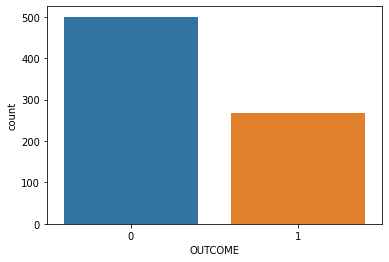

In [8]:
cat_summary(df, "OUTCOME",plot=True)

count   768.000
mean      3.845
std       3.370
min       0.000
5%        0.000
10%       0.000
20%       1.000
30%       1.000
40%       2.000
50%       3.000
60%       4.000
70%       5.000
80%       7.000
90%       9.000
95%      10.000
99%      13.000
max      17.000
Name: PREGNANCIES, dtype: float64


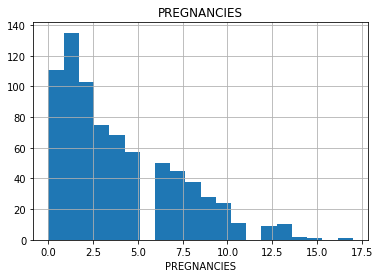

count   768.000
mean    120.895
std      31.973
min       0.000
5%       79.000
10%      85.000
20%      95.000
30%     102.000
40%     109.000
50%     117.000
60%     125.000
70%     134.000
80%     147.000
90%     167.000
95%     181.000
99%     196.000
max     199.000
Name: GLUCOSE, dtype: float64


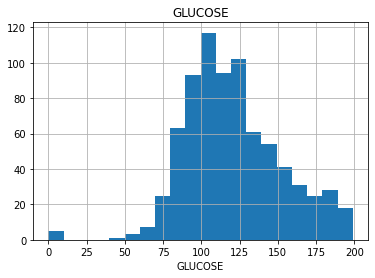

count   768.000
mean     69.105
std      19.356
min       0.000
5%       38.700
10%      54.000
20%      60.000
30%      64.000
40%      68.000
50%      72.000
60%      74.000
70%      78.000
80%      82.000
90%      88.000
95%      90.000
99%     106.000
max     122.000
Name: BLOODPRESSURE, dtype: float64


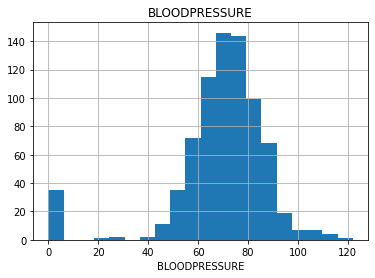

count   768.000
mean     20.536
std      15.952
min       0.000
5%        0.000
10%       0.000
20%       0.000
30%       8.200
40%      18.000
50%      23.000
60%      27.000
70%      31.000
80%      35.000
90%      40.000
95%      44.000
99%      51.330
max      99.000
Name: SKINTHICKNESS, dtype: float64


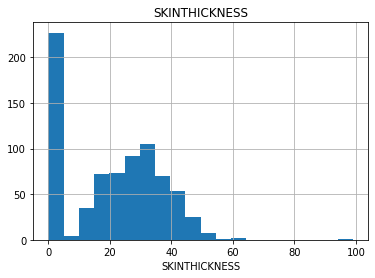

count   768.000
mean     79.799
std     115.244
min       0.000
5%        0.000
10%       0.000
20%       0.000
30%       0.000
40%       0.000
50%      30.500
60%      72.200
70%     106.000
80%     150.000
90%     210.000
95%     293.000
99%     519.900
max     846.000
Name: INSULIN, dtype: float64


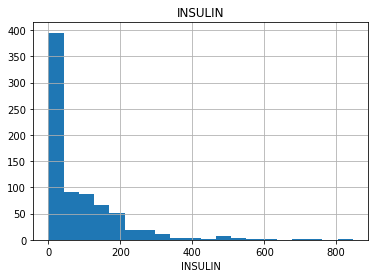

count   768.000
mean     31.993
std       7.884
min       0.000
5%       21.800
10%      23.600
20%      25.900
30%      28.200
40%      30.100
50%      32.000
60%      33.700
70%      35.490
80%      37.800
90%      41.500
95%      44.395
99%      50.759
max      67.100
Name: BMI, dtype: float64


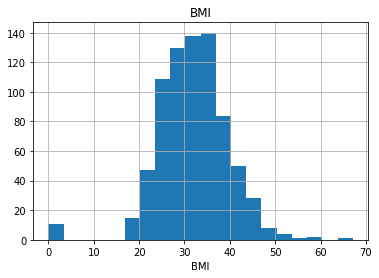

count   768.000
mean      0.472
std       0.331
min       0.078
5%        0.140
10%       0.165
20%       0.219
30%       0.259
40%       0.303
50%       0.372
60%       0.454
70%       0.564
80%       0.687
90%       0.879
95%       1.133
99%       1.698
max       2.420
Name: DIABETESPEDIGREEFUNCTION, dtype: float64


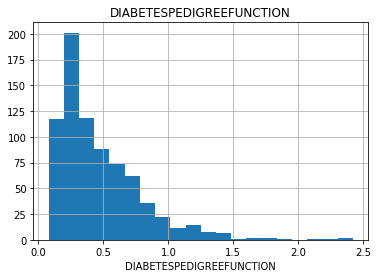

count   768.000
mean     33.241
std      11.760
min      21.000
5%       21.000
10%      22.000
20%      23.000
30%      25.000
40%      27.000
50%      29.000
60%      33.000
70%      38.000
80%      42.600
90%      51.000
95%      58.000
99%      67.000
max      81.000
Name: AGE, dtype: float64


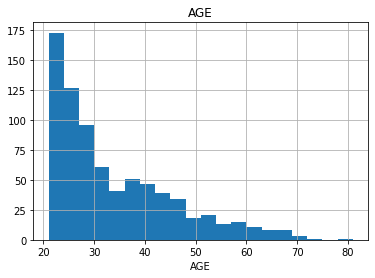

In [9]:
for col in num_cols:
    num_summary(df, col,plot=True)

In [10]:
target_summary_with_num(df,"OUTCOME",col)

           AGE
OUTCOME       
0       31.190
1       37.067




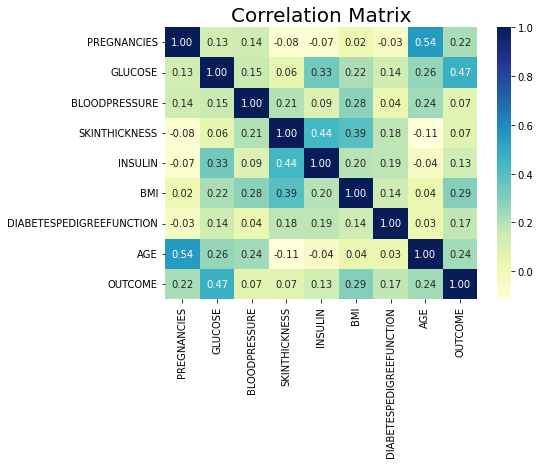

In [11]:
f, ax = plt.subplots(figsize=[7, 5])
sns.heatmap(df.corr(), annot=True, fmt=".2f", ax=ax, cmap="YlGnBu")
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

### 🔎 3. Missing Value Analysis

In [12]:
df.isnull().sum()

PREGNANCIES                 0
GLUCOSE                     0
BLOODPRESSURE               0
SKINTHICKNESS               0
INSULIN                     0
BMI                         0
DIABETESPEDIGREEFUNCTION    0
AGE                         0
OUTCOME                     0
dtype: int64

In [13]:
df[["GLUCOSE","BLOODPRESSURE","SKINTHICKNESS","INSULIN","BMI"]]= df[["GLUCOSE","BLOODPRESSURE","SKINTHICKNESS","INSULIN","BMI"]].replace(0,np.NaN)

In [14]:
na_cols = missing_values_table(df, True)

               n_miss  ratio
INSULIN           374 48.700
SKINTHICKNESS     227 29.560
BLOODPRESSURE      35  4.560
BMI                11  1.430
GLUCOSE             5  0.650


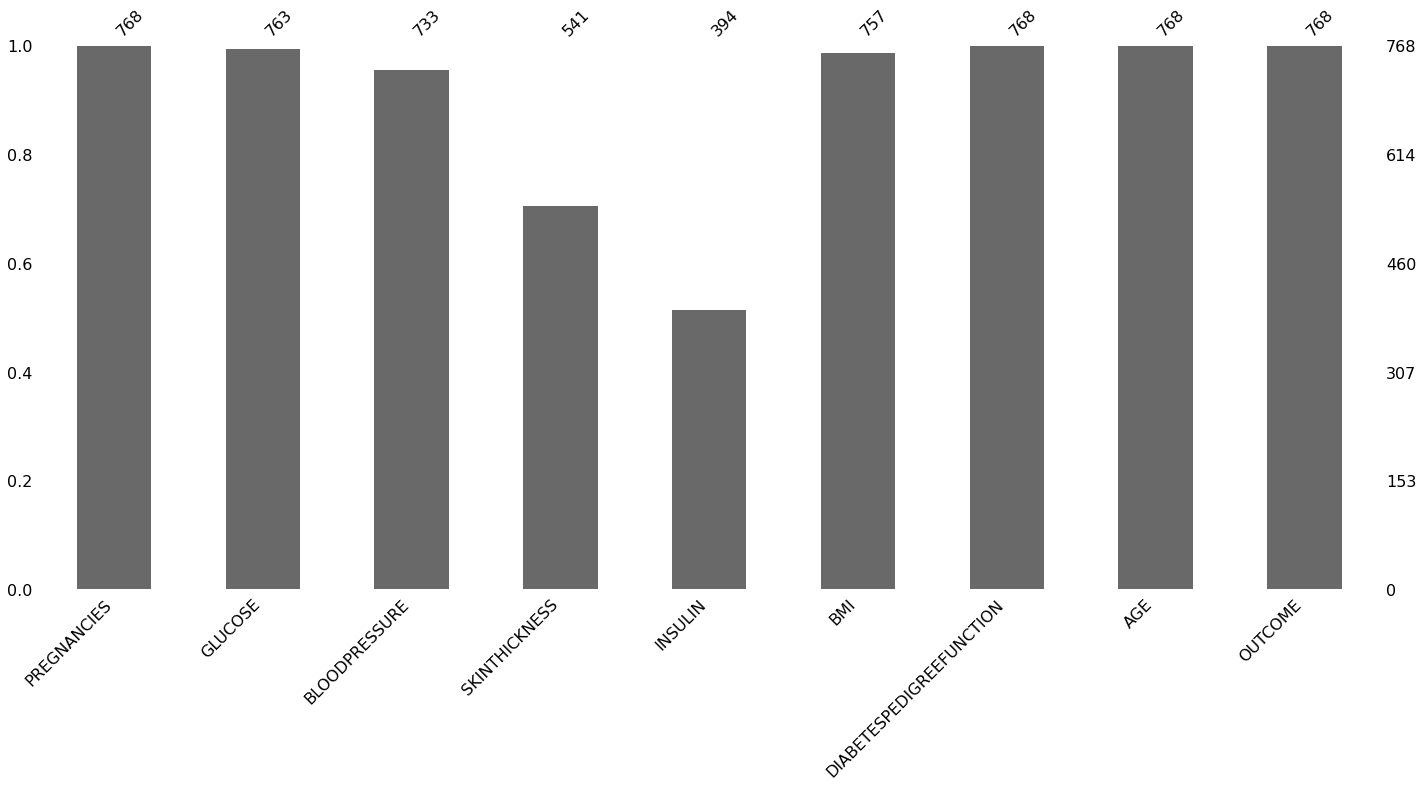

In [15]:
import missingno as msno
msno.bar(df);

In [16]:
missing_vs_target(df, "OUTCOME", na_cols)

                 TARGET_MEAN  Count
GLUCOSE_NA_FLAG                    
0                      0.349    763
1                      0.400      5


                       TARGET_MEAN  Count
BLOODPRESSURE_NA_FLAG                    
0                            0.344    733
1                            0.457     35


                       TARGET_MEAN  Count
SKINTHICKNESS_NA_FLAG                    
0                            0.333    541
1                            0.388    227


                 TARGET_MEAN  Count
INSULIN_NA_FLAG                    
0                      0.330    394
1                      0.369    374


             TARGET_MEAN  Count
BMI_NA_FLAG                    
0                  0.351    757
1                  0.182     11




In [17]:
def median_target(variable):
    temp = df[df[variable].notnull()]
    temp = temp[[variable, 'OUTCOME']].groupby(['OUTCOME'])[[variable]].median().reset_index()
    return temp

In [18]:
columns = df.columns
columns = columns.drop("OUTCOME")

for col in columns:
    df.loc[(df['OUTCOME'] == 0) & (df[col].isnull()), col] = median_target(col)[col][0]
    df.loc[(df['OUTCOME'] == 1) & (df[col].isnull()), col] = median_target(col)[col][1]

### 🔎 4. Outliers Analysis 

In [19]:
for col in num_cols:
    print(col, check_outlier(df, col))

PREGNANCIES False
GLUCOSE False
BLOODPRESSURE False
SKINTHICKNESS True
INSULIN True
BMI False
DIABETESPEDIGREEFUNCTION False
AGE False


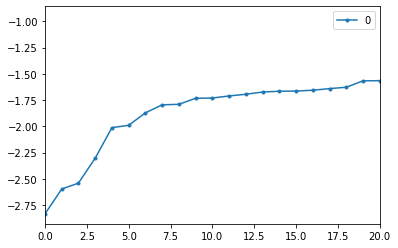

(763, 9)

In [20]:
clf = LocalOutlierFactor(n_neighbors = 20, contamination = 0.1)
clf.fit_predict(df)    # local outlıer factor skorları gelır
df_scores = clf.negative_outlier_factor_
df_scores[0:5]

scores = pd.DataFrame(np.sort(df_scores))
scores.plot(stacked=True, xlim=[0, 20], style='.-')
plt.show()

th = np.sort(df_scores)[5]
df[df_scores < th]
df[df_scores < th].shape # (5, 9)
df.describe([0.01, 0.05, 0.75, 0.90, 0.99]).T    # sebeplere bakalım

df[df_scores < th ].index
df.drop(axis=0, labels=df[df_scores < th ].index)
df = df.drop(axis=0, labels=df[df_scores < th].index)
df.head()
df.shape

### 🔎 5. Feature Engineering

In [21]:
df["NEW_BMI"] = pd.cut(x=df["BMI"], bins = [0,18.5,24.9,29.9,100], 
                       labels = [ "Underweight","Healthy","Overweight","Obese"])


# GLUCOSE As 2 plasma samples in oral glucose tolerance test
df["NEW_GLUCOSE"] = pd.cut(x=df["GLUCOSE"], bins=[0, 140, 200, 300], 
                           labels=["Normal", "Prediabetes", "Diabetes"])


# Age  : Yaş (yıl)
df["AGE"].min()  # 21
df["AGE"].max()  # 55
df.loc[(df['AGE'] <= 30), "NEW_AGE"] = "young"
df.loc[(df['AGE'] > 30) & (df["AGE"] <= 50), "NEW_AGE"] = "middle_age"
df.loc[(df['AGE'] > 50), "NEW_AGE"] = "old"
df.head()

df["NEW_AGE"].value_counts()

# BloodPressure  : Kan Basıncı
df.loc[(df['BLOODPRESSURE'] < 70), 'NEW_BLOOD_CAT'] = "hipotansiyon"
df.loc[(df['BLOODPRESSURE'] >= 70) & (df['BLOODPRESSURE'] < 90), 'NEW_BLOOD_CAT'] = "normal"
df.loc[(df['BLOODPRESSURE'] >= 90), 'NEW_BLOOD_CAT'] = "hipertansiyon"

#Insulin        : 2 saatlik serum insülini (mu U/ml)
df["NEW_INSULIN"] = pd.cut(x=df["INSULIN"],
                           bins=[0, 140, 200, df["INSULIN"].max()],
                           labels=["Normal", "Hidden_diabetes", "Diabetes"])


In [22]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 763
Variables: 14
cat_cols: 6
num_cols: 8
cat_but_car: 0
num_but_cat: 4


### 🔎 6. One- Hot Encoding

In [23]:
df = pd.get_dummies(df[cat_cols + num_cols], drop_first=True)

### 🔎 7. Feature Standarzation 

In [24]:
# Standardization for numerical cols
rs = RobustScaler()
df[num_cols] = rs.fit_transform(df[num_cols])
df.head()


,OUTCOME,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,NEW_AGE_old,NEW_AGE_young,NEW_BLOOD_CAT_hipotansiyon,NEW_BLOOD_CAT_normal,NEW_BMI_Healthy,NEW_BMI_Overweight,NEW_BMI_Obese,NEW_GLUCOSE_Prediabetes,NEW_GLUCOSE_Diabetes,NEW_INSULIN_Hidden_diabetes,NEW_INSULIN_Diabetes
0,1,0.600,0.775,0.000,1.000,1.000,0.177,0.671,1.235,0,0,0,1,0,0,1,1,0,1,0
1,0,-0.400,-0.800,-0.375,0.143,0.000,-0.597,-0.050,0.118,0,0,1,0,0,1,0,0,0,0,0
2,1,1.000,1.650,-0.500,0.571,1.000,-0.961,0.789,0.176,0,0,1,0,1,0,0,1,0,1,0
3,0,-0.400,-0.700,-0.375,-0.714,-0.127,-0.431,-0.530,-0.471,0,1,1,0,0,1,0,0,0,0,0
4,1,-0.600,0.500,-2.000,1.000,0.978,1.227,5.008,0.235,0,0,1,0,0,0,1,0,0,1,0


### 🔎 8. Model

In [25]:
y = df["OUTCOME"]
X = df.drop(["OUTCOME"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=46).fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy_score(y_pred, y_test)

0.8995633187772926

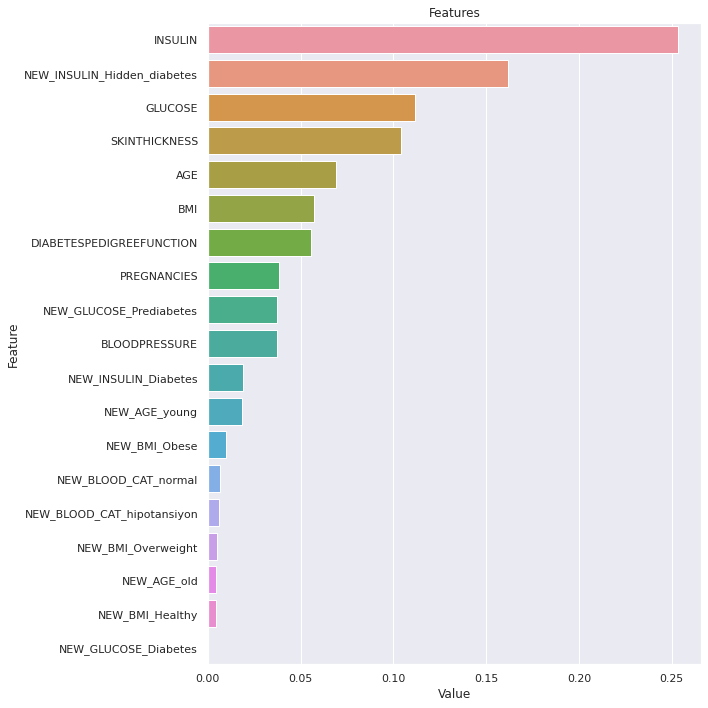

In [26]:
def plot_importance(model, features, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                      ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')
        
plot_importance(rf_model, X_train)

### 🚩 9. Conclusion :

* Diabetes dataset was used in this study. The purpose of the analysis is to predict whether a person has diabetes. Random forest classification model was used. The score is 0.8995.

-----

I❤️VBO